# Compact
Load Compact CSV files and create a DataFrame named `df`.

In [250]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Compact"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()
df_clean = df.copy()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()

Loaded 2045 rows from 214 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Compact


,Date,Title,Inhalt,URL,source,source_file
0,2025-06-11,COMPACT gegen Regierung: So war der 2. Tag!,Der zweite und letzte Verhandlungstag im COMPACT-Verbotsverfahren ist abgeschlossen. Das Urteil wird am 24.06. bekannt gegeben. Wie verlief es heute vor Gericht? Wessen Chancen stehen am Ende besser? Kann sich die Regierung durchsetzen oder obsiegt die Pressefreiheit? Eine Analyse und die Prognose zu diesem historischen Verfahren liefern Ihnen das Ehepaar Elsässer und Paul Klemm.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,https://www.compact-online.de/compact-gegen-regierung-so-war-der-2-tag/,Compact,Compact_2025-06-11_raw.csv
1,2025-06-11,COMPACT-Verbot 2024: Der Film,"Als Nancy Faeser eskalierte. Die denkwürdigsten Szenen des 16. Juli 2024, also plötzlich die Formate von COMPACT verboten wurden.\n\nUnser Cutter hat anlässlich des laufenden Verbotsverfahren die bemerkenswertesten Szenen zusammengeschnitten.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/compact-verbot-2024-der-film/,Compact,Compact_2025-06-11_raw.csv
2,2025-06-11,Drogen und Rituale: Mysteriöse Inka-Stätte entdeckt,"Ein neuer Fund in den peruanischen Anden eröffnet einen neuen Blick auf die Kultur der Inka: Sie waren nicht nur große Baumeister, sondern erforschten auch astronomische und spirituelle Geheimnisse – unter Einsatz psychoaktiver Substanzen. Mehr über die Frühzeit der Menschheit und historische Ungereimtheiten lesen Sie „Geheime Geschichte – Von den Pharaonen bis zur Kabale im Vatikan“ – unserer neuen Geschichtsausgabe. Hier mehr erfahren. \n\nHoch oben in den schroffen Felsen der peruanischen Anden, auf fast 3.000 Metern Höhe, haben Archäologen eine Entdeckung gemacht, die nicht nur die Fachwelt elektrisiert: Ein geheimer, unterirdischer Raum, der vermutlich seit Jahrtausenden unberührt war, gibt nun Einblicke in die mysteriösen Rituale der Inka – jenes alten lateinamerikanischen Volkes, das um die Hauptstadt Cusco im heutigen Peru lebte und ab 1438 viele Gebiete eroberte, insbesondere im Anden-Gebirge. Das Reich der Inka gilt als das größte seiner Zeit und umfasste schätzungsweise ...",https://www.compact-online.de/drogen-und-rituale-mysterioese-inka-staette-entdeckt/,Compact,Compact_2025-06-11_raw.csv
3,2025-06-11,Trumps Einsatz in Los Angeles: Ein Medientrauma,"Das Durchgreifen des US-Präsidenten gegen das Treiben illegaler Einwanderer in Los Angeles treibt etablierte Medien um. Wir zeigen auf, wie Trump tickt und was wir von ihm noch zu erwarten haben. Sichern Sie sich am besten gleich unsere Sonderausgabe „Trump. Sein Leben. Seine Politik. Sein großes Comeback.“ Hier mehr erfahren.\n\nDie Straßen von Los Angeles stehen in Flammen – brennende Polizeiwagen, fliegende Steine und Proteste. Die Szenen lassen an einen Bürgerkrieg denken. Auslöser der Krawalle waren Razzien der Einwanderungsbehörden gegen illegale Migranten. Präsident Donald Trump reagiert entschlossen und schickt 2.000 Soldaten der Nationalgarde sowie 700 Marines, um die Gewalt in den Griff zu bekommen – ein Schritt, der weltweit für Schlagzeilen sorgt. Die internationale Presse ist in Aufruhr, die Meinungen aus der Straße sind gespalten.\n\nTrumps Entscheidung, Kaliforniens Gouverneur Gavin Newsom und die Bürgermeisterin von Los Angeles, Karen Bass, beide Demokraten, zu über...",https://www.compact-online.de/trumps-einsatz-in-los-angeles-ein-medientrauma/,Compact,Compact_2025-06-11_raw.csv
4,2025-06-11,Verrat an BismarckCOMPACT+,"Essay von Rolf Hochhut. Deutschland hat seinen großen Kanzler vergessen – vor allem von seiner klugen Ausgleichspolitik mit Russland wollen die heutigen NATO-Vasallen nichts mehr wissen. _ von Rolf Hochhuth Bismarcks geheimer Rückversicherungsvertrag mit Russland sah vor: Berlin und Petersburg bleiben «wohlwollend neutral», wird eines der beiden Länder «in Krieg mit einer Großmacht verwicke

In [251]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
Date,0,0.0
Title,0,0.0
Inhalt,0,0.0
URL,0,0.0
source,0,0.0
source_file,0,0.0


In [252]:
# filter timeframe Aug 2025 through Jan 2026 (inclusive)
start, end = "2025-08-01", "2026-01-31"
dates = pd.to_datetime(df_clean["Date"], errors="coerce")
mask = (dates >= start) & (dates <= end)

df_aug2025_jan2026 = df_clean.loc[mask].copy()
df_aug2025_jan2026["Date"] = pd.to_datetime(df_aug2025_jan2026["Date"])
df_clean = df_aug2025_jan2026.copy()

print(f"Rows in selected period: {len(df_clean)}")
df_clean.sort_values("Date").head()

Rows in selected period: 1614


,Date,Title,Inhalt,URL,source,source_file
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/,Compact,Compact_2025-08-01_raw.csv
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/,Compact,Compact_2025-08-01_raw.csv
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/,Compact,Compact_2025-08-01_raw.csv
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/,Compact,Compact_2025-08-01_raw.csv
348,2025-08-01

In [253]:
# keep only the requested columns
_keep = ["Date", "Title", "Inhalt", "URL"]

if 'df_clean' in globals():
    df_clean = df_clean.loc[:, _keep].copy()

if 'df_aug2025_jan2026' in globals():
    df_aug2025_jan2026 = df_aug2025_jan2026.loc[:, _keep].copy()

if 'df' in globals():
    df = df.loc[:, _keep].copy()

# show result
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nich

In [254]:
from IPython.display import display
display(df_clean.head(3))

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/


Removal of "Mehr zum Thema"

In [255]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Inhalt"] = df_clean["Inhalt"].apply(remove_mehr_zum_thema)

In [256]:
df_clean.head()

,Date,Title,Inhalt,URL
344,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,2025-08-01,Ein Polizist aus dem Volk,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,2025-08-01,SPD-Politiker fordert Rückzug von Brosius-Gersdorf,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,2025-08-01,Die große Vertuschung,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nich

In [257]:
!pip install seaborn

In [258]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy() if "df_clean" in globals() else df.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

text_col = "Inhalt"
eda_df[text_col] = eda_df[text_col].astype("string")
eda_df = eda_df.dropna(subset=["Date", text_col]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 1,614


In [259]:
eda_df["article_length_words"] = eda_df[text_col].str.split().str.len()
eda_df["article_length_chars"] = eda_df[text_col].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    1614.0
mean      495.9
std       481.7
min        23.0
10%        70.0
25%       118.0
50%       419.0
75%       670.2
90%      1118.2
95%      1479.7
99%      2201.0
max      4324.0
Name: article_length_words, dtype: float64

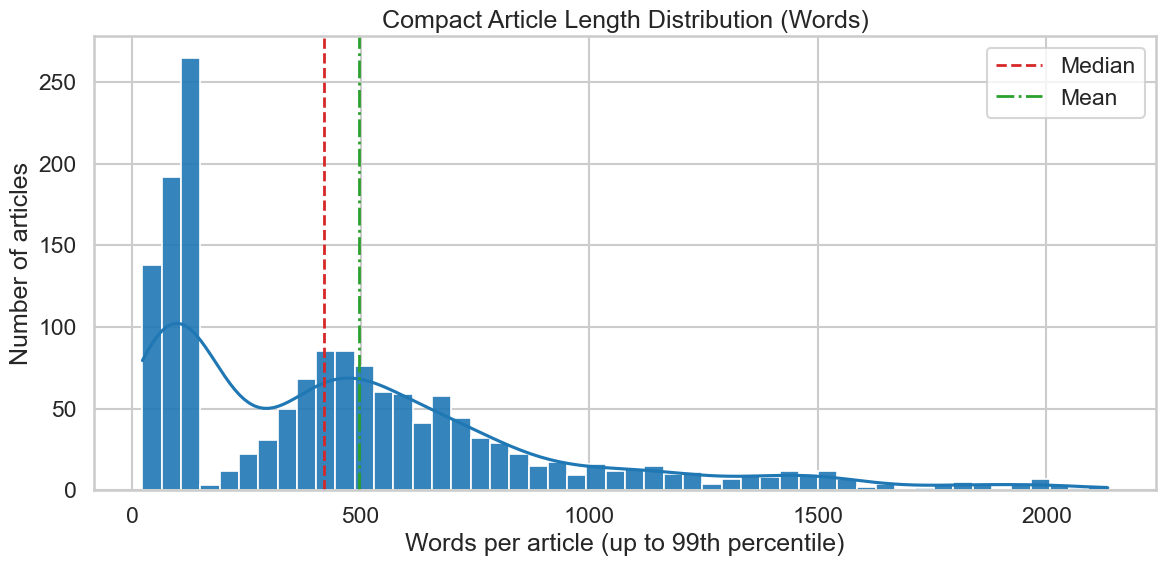

In [260]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Compact Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

In [261]:
# Inspect 20 shortest articles by word count
df_inspect = eda_df if "eda_df" in globals() else df_clean.copy()

if "article_length_words" not in df_inspect.columns:
    df_inspect["article_length_words"] = df_inspect["Inhalt"].astype("string").str.split().str.len()

# ensure source column exists (most data is from SOURCE_NAME == "Compact")
if "source" not in df_inspect.columns:
    df_inspect["source"] = SOURCE_NAME if "SOURCE_NAME" in globals() else "Compact"

# build result (Title, text, source, word_count) sorted ascending
shortest = (
    df_inspect.sort_values("article_length_words", ascending=True)
    .loc[:, ["Title", "Inhalt", "source", "article_length_words"]]
    .head(20)
    .rename(columns={"Inhalt": "text", "article_length_words": "word_count"})
)

# allow longer text columns to be displayed
pd.options.display.max_colwidth = 1000

display(shortest)

,Title,text,source,word_count
632,Macron am Boden: Live beim Aufstand!,Frankreich im Ausnahmezustand – COMPACT ist live vor Ort dabei!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,23
594,Albaner (18) sticht auf Lehrerin ein! NOT-OP!,Amoklauf in Essener Schule. SEK muss schießen. Dr. Stephanie Elsässer klärt auf!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,25
646,MOSSAD und 9/11,Heute vor 24 Jahren: Israelische Geheimdienstler wurden nach den Anschlägen des 11. September 2001 vom FBI festgenommen und zwei Monate eingesperrt. Waren sie in das Terrorkomplott verwickelt?,Compact,27
464,„Remigration!“: Söder-Interview wird abgebrochen!,Aufregung am Bundestag! Das Sommer-Interview der ARD mit CSU-Chef Söder muss abgebrochen werden.\n\nWir sind vor Ort!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.,Compact,30
1187,Halle (Saale): Antifa brüllt gegen Buchmesse,"Wirbel um die «Seitenwechsel»-Buchmesse in Halle (Saale).\n\nSehen Sie hier brüllende Antifas, spannende Interviews und Impressionen von unserem Messestand!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,32
1901,Vor Ort: Orban geht gegen Hammerbande vor!,"In Budapest strebt der Prozess gegen Hammerbanden-„Maja“ seinem Höhepunkt entgegen. Unser Korrespondent Sebastian Schmidtke ist dabei und dokumentiert, wie deutsche Politiker vor Ort Stimmung machen.\n\nDie Reportage sehen Sie in dem Video oben.",Compact,33
1388,AfD-Jugend: COMPACT beim Kampf um Gießen!,"Ausnahmezustand in Gießen: Tausende Antifa wollen den Gründungskongress der AfD-Jugend stürmen! Blockaden, Wasserwerfer, Angriffe auf Polizisten und Teilnehmer. COMPACT mittendrin!\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Compact,33
1575,Gefahr Migration: Ex-Islamist packt aus!,Irfan Peci war Propaganda-Chef der deutschen al-Qaida! Inzwischen hat er zum christlichen Glauben gefunden und warnt vor den schrecklichen Folgen der Massenmigration. Was steht Deutschland bevor?\n\nUnsere heutige Shop-Empfehlung: „COMPACT-Spezial 45: Mädchen. Messer. Morde“,Compact,34
1656,Rückblick: Unsere größten TV-Highlights!,Nur noch wenige Stunden… – 2025 war ein spektakuläres Jahr mit vielen Höhen und Tiefen. In unserem COMPACT-Rückblick sehen Sie die wichtigsten Ereignisse in einer kurzweiligen Zusammenfassung. Wir wünschen einen frohen Jahreswechsel und ein gesundes Neues!,Compact,36
1692,Spreewald: Wird SIE die erste AfD-Landrätin?,Widerstand im Gurkenland: Der Kreis Oberspreewald-Lausitz gilt als AfD-Hochburg. In wenigen Tagen wird hier ein neuer Landrat gewählt. Die blaue Kandidatin hat gute Chancen. Paul Klemm hat sie mit der Kamera begleitet.\n\nUnsere heutige Produktempfehlung: Silbermedaille Höcke-Taler,Compact,37


--> This indicates two types of documents in the corpus: News briefs / ticker posts and Normal articles

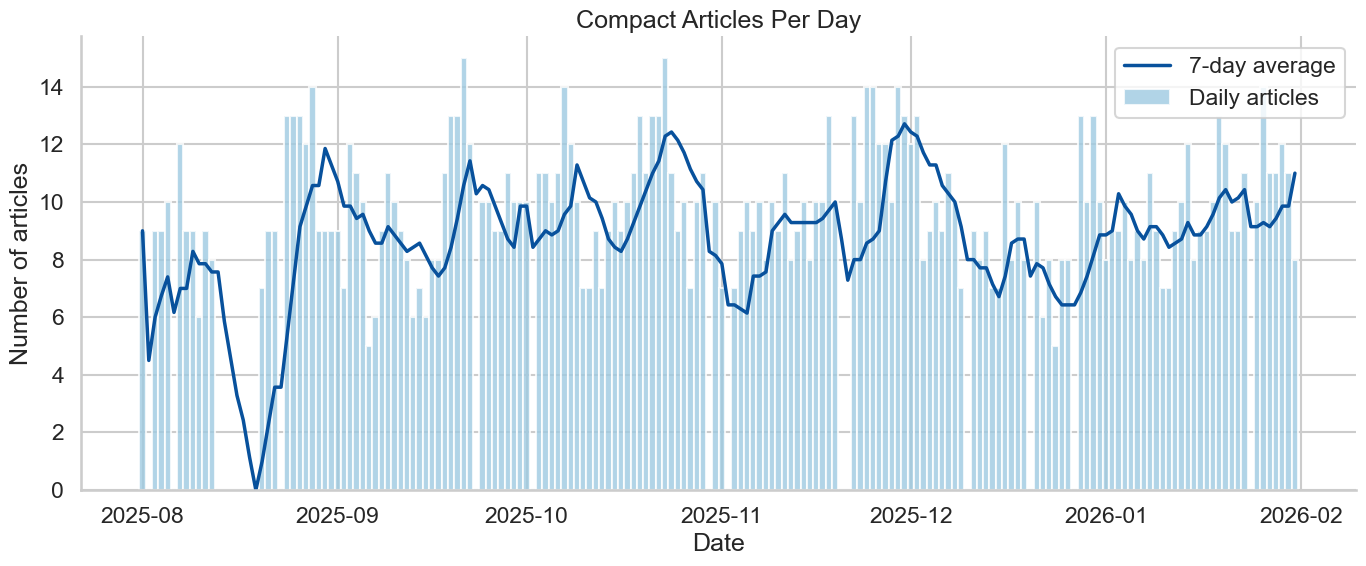

In [262]:
daily_counts = (
    eda_df.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("Compact Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## BERTopic

In [263]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "02_TopicModeling").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 02_TopicModeling")

project_root = resolve_project_root()
module_root = project_root / "02_TopicModeling"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

In [264]:
from bertopic_config import BERTopicConfig, title_config
from bertopic_pipeline import run_bertopic_pipeline


In [265]:
df_clean[["Inhalt", "Title", "URL"]].head()


,Inhalt,Title,URL
344,"„Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie!\n\nDr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.\n\nCOMPACT-TV ist für Sie gratis! Bitte spenden Sie zu unserer Unterstützung unter compact-online.de/unterstuetzen.",Blond! Linker Hass gegen Jeans-Model,https://www.compact-online.de/blond-linker-hass-gegen-jeans-model/
345,"Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen.\n\nDiese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik eingeladen.\n\nDas Buch von Mearshei...",Die Macht der Israel-Lobby in den USA,https://www.compact-online.de/die-macht-der-israel-lobby-in-den-usa/
346,"Karsten Hilse im Porträt. Ein Menetekel: Am Tag der Verabschiedung der Notstandsgesetze wird der Bundestagsabgeordnete Karsten Hilse festgenommen und brutal auf den Asphalt gedrückt – er, der selbst 30 Jahre lang Polizist war. Dieser Artikel erschien im COMPACT-Spezial 35: „Politische Verfolgung“. _ von Paul Klemm Warum er keine Mund-Nasen-Bedeckung trage, wollen die Polizisten von Karsten Hilse wissen. Der AfD-Bundestagsabgeordnete ist an diesem 18. November 2020 auf dem Weg zum Brandenburger Tor, wo er dem Petitionsausschuss\n\nDieser Inhalt aus unserer Printausgabe ist registrierten Benutzern vorbehalten.\n\nBitte loggen Sie sich hier ein, oder holen Sie sich jetzt den Digital - Pass für Smartphone, Tablet und Desktop\n\nAnmelden\nBenutzername oder E-Mail-Adresse\nPasswort\n Angemeldet bleiben \nPasswort vergessen? Klicke hier, um es zurückzusetzen.",Ein Polizist aus dem Volk,https://www.compact-online.de/ein-polizist-aus-dem-volk/
347,"Die Bundesregierung möchte die politischer Sommerpause nutzen, um die Reihen wieder zu schließen. Die Kandidatur der umstrittenen Juristin Frauke Brosius-Gersdorf galt für die SPD jedoch lange als unverhandelbar. Jetzt fordert ein prominenter Genosse erstmals den Rückzug. Gut so, denn mit dieser Verfassungsrichterin würde die autoritäre Links-Republik für viele Jahre zementiert. Wie schlimm die Zustände bereits sind, haben wir im COMPACT-Rabattpaket „1.000 Seiten BRD-Diktatur“ zusammengetragen. Jetzt erhältlich für nur 14,99 Euro (statt für 79,75 Euro). Hier mehr erfahren.\n\nWährend Friedrich Merz eine klare Aussage zur möglichen Wahl von Frauke Brosius-Gersdorf vermeidet und intern versucht, Abweichler auf Kurs zu bringen, meldet sich jetzt mit Brandenburgs Ministerpräsidenten Dietmar Woidke ein SPD-Veteran zu Wort, dessen Stimme Gewicht hat. Und Woidke fordert einen kompletten Neuanfang, den Rückzug aller drei Kandidaten für das Bundesverfassungsgericht – neben den beiden Linksa...",SPD-Politiker fordert Rückzug von Brosius-Gersdorf,https://www.compact-online.de/spd-politiker-fordert-rueckzug-von-brosius-gersdorf/
348,"Epstein, Epstein, alles muss versteckt sein: Tausende Dokumente bleiben unter Verschluss, eine Klientenliste gibt es angeblich gar nicht. Trumps Kehrtwende wirft Fragen auf – und bringt die Gerüchteküche zum Brodeln. 

In [266]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "01_EDAperOutlet" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("Compact")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical Compact subset from df_combined: {len(df_clean):,} rows")


Loaded canonical Compact subset from df_combined: 1,486 rows


In [267]:
# 1) BERTopic on Compact documents with outlet-specific cleanup
# Compact article bodies contain recurring shop / self-promo copy, but a setup that is
# too permissive also over-splits this medium-sized corpus into microtopics. Use title+text
# as the main representation and a more moderate clustering profile.
compact_topic_df = df_clean.copy()
compact_topic_df["topic_text"] = (
    compact_topic_df["Title"].fillna("").astype(str).str.strip()
    + ". "
    + compact_topic_df["Text"].fillna("").astype(str).str.strip()
).str.replace(r"^\.\s*", "", regex=True).str.strip()

compact_extra_boilerplate_patterns = (
    r"(?is)hier\\s+mehr\\s+erfahren\\.?",
    r"(?is)hier\\s+bestellen\\.?",
    r"(?is)jetzt\\s+(?:hier\\s+)?bestellen\\.?",
    r"(?is)unbedingt\\s+einschalten\\.?",
    r"(?is)abonnieren\\s+sie\\s+gleich\\s+unseren\\s+youtube-kanal.*?(?:\\.|\\Z)",
    r"(?is)aktivieren\\s+die\\s+glocke.*?(?:\\.|\\Z)",
    r"(?is)um\\s+keine\\s+sendung\\s+mehr\\s+zu\\s+verpassen\\.?",
    r"(?is)compact-tv[^\\n\\.]*[\\.]?",
    r"(?is)brennpunkt[^\\n\\.]*[\\.]?",
    r"(?is)halten\\s+sie\\s+sich\\s+lieber\\s+an\\s+die\\s+compact-biografie[^\\n\\.]*[\\.]?",
    r"(?is)garantiert\\s+ohne\\s+hass\\s+und\\s+hetze\\.?",
    r"(?is)in\\s+der\\s+(?:aktuellen\\s+)?compact-(?:ausgabe|spezial|geschichte)[^\\n\\.]*[\\.]?",
    r"(?is)unsere\\s+(?:sonderausgabe|ausgabe|spezial-ausgabe|spezial)[^\\n\\.]*[\\.]?",
    r"(?is)unser\\s+(?:rabatt-paket|rabattpaket|argumenten-arsenal|sonderheft)[^\\n\\.]*[\\.]?",
)

compact_extra_stopwords = (
    "compact",
    "tv",
    "youtube",
    "kanal",
    "glocke",
    "ausgabe",
    "sonderausgabe",
    "sonderheft",
    "spezial",
    "titelthema",
    "rabattpaket",
    "rabatt",
    "paket",
    "bestellen",
    "erfahren",
    "medaille",
    "button",
    "shop",
    "magazin",
    "heft",
    "brennpunkt",
    "biografie",
)

config_full_text = BERTopicConfig(
    min_df=2,
    max_df=0.85,
    umap_n_neighbors=18,
    umap_min_dist=0.05,
    hdbscan_min_cluster_size=12,  # raised from 10; reduces microtopics without nr_topics cap
    hdbscan_min_samples=3,
    hdbscan_cluster_selection_method="eom",
    nr_topics=None,
    extra_stopwords=compact_extra_stopwords,
    boilerplate_patterns=BERTopicConfig().boilerplate_patterns + compact_extra_boilerplate_patterns,
)

result_full_text = run_bertopic_pipeline(
    df=compact_topic_df,
    text_col="topic_text",
    config=config_full_text,
    id_col="row_id",
    source_name="Compact",
)

# 2) BERTopic on titles only
config_title = title_config(
    min_df=1,
    max_df=0.9,
    umap_n_neighbors=14,
    umap_min_dist=0.05,
    hdbscan_min_cluster_size=10,
    hdbscan_min_samples=3,
    extra_stopwords=compact_extra_stopwords,
)

result_title = run_bertopic_pipeline(
    df=compact_topic_df,
    text_col="Title",
    config=config_title,
    id_col="row_id",
    source_name="Compact",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 18:59:04,790 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

2026-03-31 18:59:12,482 - BERTopic - Embedding - Completed ✓
2026-03-31 18:59:12,483 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 18:59:14,705 - BERTopic - Dimensionality - Completed ✓
2026-03-31 18:59:14,706 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 18:59:14,735 - BERTopic - Cluster - Completed ✓
2026-03-31 18:59:14,738 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 18:59:15,256 - BERTopic - Representation - Completed ✓


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 18:59:20,367 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

2026-03-31 18:59:21,899 - BERTopic - Embedding - Completed ✓
2026-03-31 18:59:21,899 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 18:59:24,025 - BERTopic - Dimensionality - Completed ✓
2026-03-31 18:59:24,026 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 18:59:24,044 - BERTopic - Cluster - Completed ✓
2026-03-31 18:59:24,046 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 18:59:24,068 - BERTopic - Representation - Completed ✓


In [268]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,475,-1_russland_berlin_merz_krieg,"[russland, berlin, merz, krieg, mann, us, partei, ukraine, naidoo, später, politische, zwar, ihrem, dezember, buch, frieden, paul, nord, ihm, spd, regierung, natürlich, nord stream, stream, 14, frage, tag, deutsch, druschba, eu]","[Flamingos gegen Moskau. Die Merz-Regierung baut weitreichende Waffensysteme für die Ukraine – und will damit die Führungsrolle im Krieg gegen Russland übernehmen. Ein Auszug aus unserer aktuellen Spezial-Ausgabe «Krieg gegen Russland». Deutschlands dritter Marsch ins Verderben! Hier mehr erfahren. «So knapp waren wir 1941 vor der Einnahme Moskaus. Dieses Mal klappt es!» Das hat er natürlich nicht gesagt, der Generalmajor Christian Freuding, ab September 2025 Oberkommandierender des deutschen Heeres. Foto: picture alliance/dpa «Der Krieg muss nach Russland getragen werden. (…) Wir müssen alles tun, dass die Ukraine in die Lage versetzt wird, nicht nur Ölraffinerien in Russland zu zerstören, sondern Ministerien, Kommandoposten, Gefechtsstände.» Wenn ein Wadenbeißer wie der CDU-Verteidigungspolitiker Roderich Kiesewetter Angriffe auf Ziele im Herzen Russlands fordert, so geschehen im Februar 2024, ist das schlimm genug. Nun aber hat der künftige Oberbefehlshaber des deutschen Heeres ..."
1,0,82,0_antifa_wehrpflicht_chrupalla_weidel,"[antifa, wehrpflicht, chrupalla, weidel, beifall, beifall afd, höcke, szene, partei, grünen, 90, lucassen, alice, alice weidel, 90 grünen, gießen, bündnis, bündnis 90, polizei, linke, linken, baumann, tino chrupalla, gewalt, tino, demonstration, wiedereinführung, bundestag, wiedereinführung wehrpflicht, bundestagsfraktion]","[Eklat: AfD-Stahlhelmer schießt gegen Höcke und Chrupalla. Unglaublicher Eklat im Bundestag. In der Wehrgesetz-Debatte heute Vormittag schießt der AfD-Abgeordnete Rüdiger Lucassen öffentlich gegen Höcke, weil dieser die Wehrpflicht ablehnt. Dabei vertritt Höcke an diesem Punkt nur die Parteilinie, die Tino Chrupalla in der Bundestagsfraktion durchgesetzt hat. Chrupalla ist der Mann, der die AfD auf Friedenskurs hält – aber einige AfD-Stahlhelmer rebellieren noch immer dagegen. In unserer neuen COMPACT-Ausgabe können Sie mehr erfahren. Das hat es noch nide zuvor gegeben: Ein AfD-Bundestagsabgeordneter nutzt seine Rede im Bundestag, um die eigenen Leute anzugreifen! So geschehen heute Vormittag in der Debatte zur Wehrpflicht. Es war Rüdiger Lucassen, ein ehemaliger Bundeswehroffizier, der dieses Foul beging – gegen Björn Höcke, den Thüringer Landesvorsitzenden. Und das ausgerechnet an diesem Freitag, wo an 90 Schulen bundesweit gegen die Wehrpflicht gestreikt wird. Schlimmer kann man..."
2,1,61,1_ruhs_buch_julia ruhs_julia,"[ruhs, buch, julia ruhs, julia, wahrheit, gesteuerte wahrheit, röper, gesteuerte, links, bystron, combs, brd, journalisten, spiegel, meinungsfreiheit, weimer, links grüne, mich, stadtbild, diddy, ihrem, mainstream, freimaurer, grüne, kritik, meinung, linke, sagen, bolz, öffentlich]","[Ein Labyrinth aus Manipulation und Propaganda. Die Spatzen pfeifen es von den Dächern: Einflussreiche Thinktanks, Netzwerke und Geheimdienste nehmen Einfluss auf die Berichterstattung der Medien. In seinem neuen Enthüllungswerk „Gesteuerte Wahrheit“ belegt Thomas Röper, dass es noch viel schlimmer ist, als man bisher dachte. Hier mehr erfahren. In einer Zeit, in der die Mainstream-Nachrichten wie ein endloser Strom aus vorgefilterter Realität auf uns einprasseln, stellt sich die entscheidende Frage: Wer dreht eigentlich am Regler unserer Wahrnehmung? Thomas Röper, Macher von Anti-Spiegel und Russland-Insider, geht in seinem neuen Enthüllungswerk „Gesteuerte Wahrheit: Wie Politik, NGOs und Geheimdienste westliche Medien lenken“ genau dieser Frage nach und deckt Geheimdienstverstrickungen, politische Manipulationen und das Wirken von Hintergrundorganisationen auf, die der Öffentlichkeit in der Regel verborgen bleiben. Ein echter Augenöffner! Die Stiftungen und NGOs 

In [269]:
doc_info = result["doc_info"]
doc_info.head()

,original_index,document_id,source_name,row_id,source,Date,Title,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,0,566,Compact,566,Compact,2025-08-01,Blond! Linker Hass gegen Jeans-Model,"Blond! Linker Hass gegen Jeans-Model. „Blonde Haare, blaue Augen, tolles Erbmaterial.“ Wenn anstelle von Multikulti-Fantasien einmal Vertreter dieser „eklig weißen Mehrheitsgesellschaft“ in einer Reklame auftauchen, drehen Linke, Grüne und Co. am Rad – und wie! Dr. Stephanie Elsässer und Paul Klemm haben diesen Affront für die woke Blase ganz genau analysiert.",-1,-1_russland_berlin_merz_krieg,"[russland, berlin, merz, krieg, mann, us, partei, ukraine, naidoo, später, politische, zwar, ihrem, dezember, buch, frieden, paul, nord, ihm, spd, regierung, natürlich, nord stream, stream, 14, frage, tag, deutsch, druschba, eu]","[Flamingos gegen Moskau. Die Merz-Regierung baut weitreichende Waffensysteme für die Ukraine – und will damit die Führungsrolle im Krieg gegen Russland übernehmen. Ein Auszug aus unserer aktuellen Spezial-Ausgabe «Krieg gegen Russland». Deutschlands dritter Marsch ins Verderben! Hier mehr erfahren. «So knapp waren wir 1941 vor der Einnahme Moskaus. Dieses Mal klappt es!» Das hat er natürlich nicht gesagt, der Generalmajor Christian Freuding, ab September 2025 Oberkommandierender des deutschen Heeres. Foto: picture alliance/dpa «Der Krieg muss nach Russland getragen werden. (…) Wir müssen alles tun, dass die Ukraine in die Lage versetzt wird, nicht nur Ölraffinerien in Russland zu zerstören, sondern Ministerien, Kommandoposten, Gefechtsstände.» Wenn ein Wadenbeißer wie der CDU-Verteidigungspolitiker Roderich Kiesewetter Angriffe auf Ziele im Herzen Russlands fordert, so geschehen im Februar 2024, ist das schlimm genug. Nun aber hat der künftige Oberbefehlshaber des deutschen Heeres ...",russland - berlin - merz - krieg - mann - us - partei - ukraine - naidoo - später - politische - zwar - ihrem - dezember - buch - frieden - paul - nord - ihm - spd - regierung - natürlich - nord stream - stream - 14 - frage - tag - deutsch - druschba - eu,0.000000,False
1,1,567,Compact,567,Compact,2025-08-01,Die Macht der Israel-Lobby in den USA,"Die Macht der Israel-Lobby in den USA. Die beinharte Unterstützung Donald Trumps für den genozidalen Kriegskurs von Netanjahu in Gaza, aber auch seine Unterstützung für den Angriff Israels auf den Iran und die Unterdrückung der Epstein-Kundenliste haben viele seiner Unterstützer sehr enttäuscht. Offensichtlich befindet sich der Präsident, willenlich oder unwillentlich, im Griff einer mächtigen Lobby, die mit dem Begriff „Tiefer Staat“ zu unscharf beschrieben ist. In der aktuellen COMPACT-Ausgabe können Sie im Dossier „Präsident im Zwielicht“ mehr über diese Lobby lesen. Diese Pressure-Group sei die „Israel-Lobby“, behaupten die amerikanischen Politologen John Mearsheimer und Stephen M. Walt in ihrem gleichnamigen Buch. Die Professoren gehören zum US-Establishment: Mearsheimer lehrt an der Universität von Chicago, Walt in Harvard. Zur Vorstellung der deutschen Ausgabe ihres Werkes wurden sie Anfang der nuller Jahre von der renommierten Deutschen Gesellschaft für Auswärtige Politik e...",14,14_israel_gaza_netanjahu_hamas,"[israel, gaza, netanjahu, hamas, israelischen, israels, israelische, gazastreifen, brandstifter, palästinenser, trump, geiseln, brandstifter netanjahu, kirk, the, netanjahu welt, welt anzündet, anzündet, gazastreifens, palästinensische, palästinensischen, palästina, treffen, lobby, pro, netanjahus, sagte, freilassung, anzündet finden, wichtige hintergründe]","[Israel plant neue Großoffensive auf Gaza. Die Waffenruhe hält noch, aber neue Kriegspläne liegen bereits in der Schublade. Israels Militärführung hat offenbar konkrete Pläne für ein erneutes Vorgehen im Gazastreifen ausgearbeitet, das im März beginnen könnte. Netanjahu wartet auf das OK von Trump. In unserer Ausgabe 7/25 mit dem Titelthema „Der Brandstifter – Wie Netanjahu d

In [270]:
compact_topics = df_clean.reset_index().merge(
    doc_info[["original_index", "Topic", "Name", "Probability"]],
    left_on="index",
    right_on="original_index",
    how="left",
)

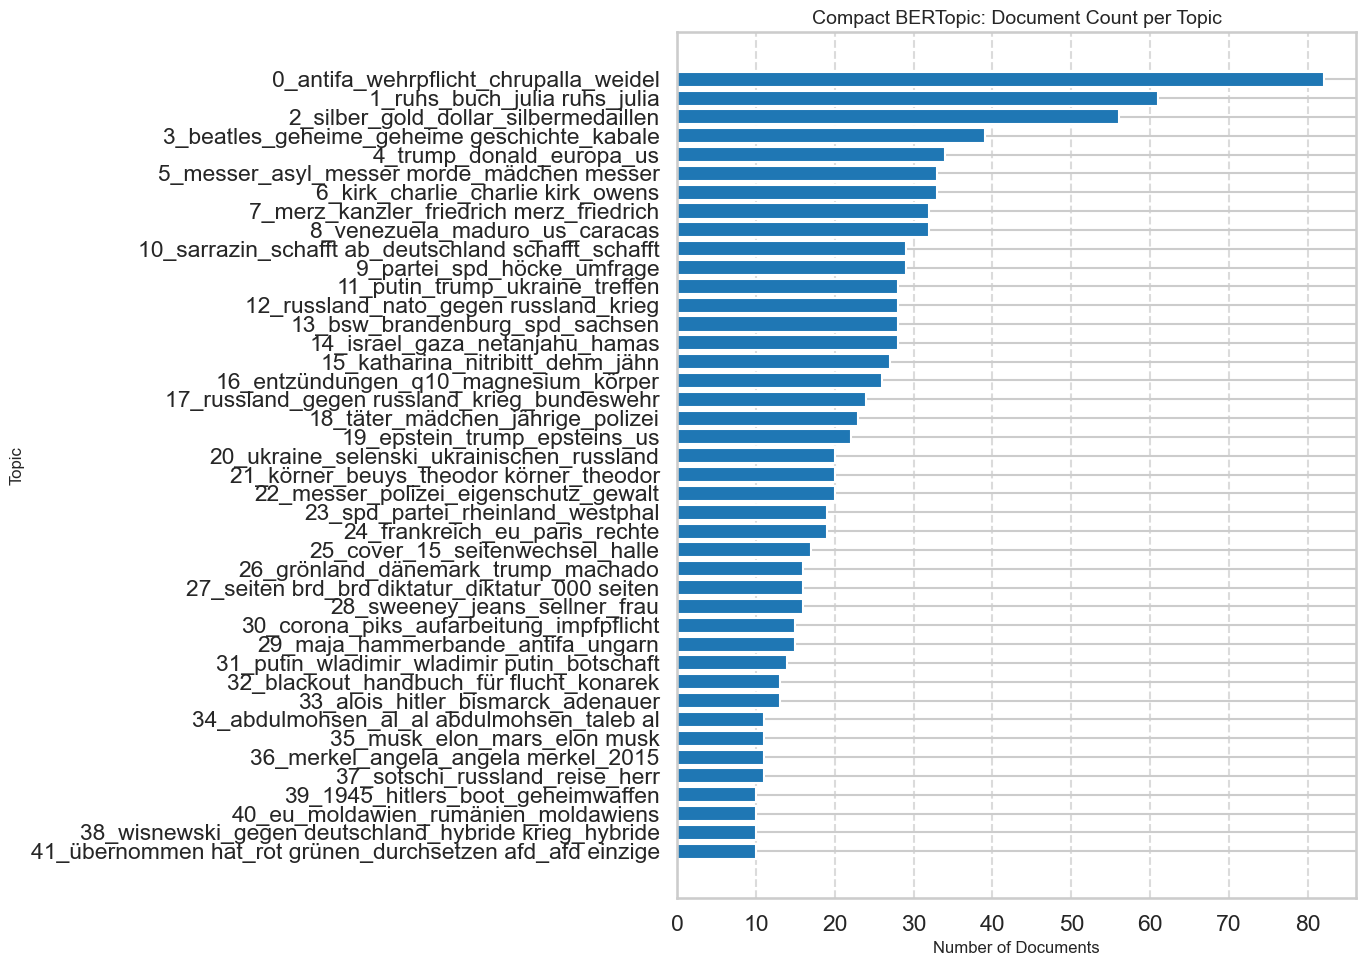

In [271]:
fig, ax = plt.subplots(figsize=(14, 10))

# Exclude topic -1 (outliers) for cleaner visualization
topic_counts = topic_info[topic_info['Topic'] != -1].copy()
topic_counts = topic_counts.sort_values('Count', ascending=True)

ax.barh(topic_counts['Name'], topic_counts['Count'], color='#1f77b4', edgecolor='white')

ax.set_xlabel('Number of Documents', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.set_title('Compact BERTopic: Document Count per Topic', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6it [00:01,  3.88it/s]


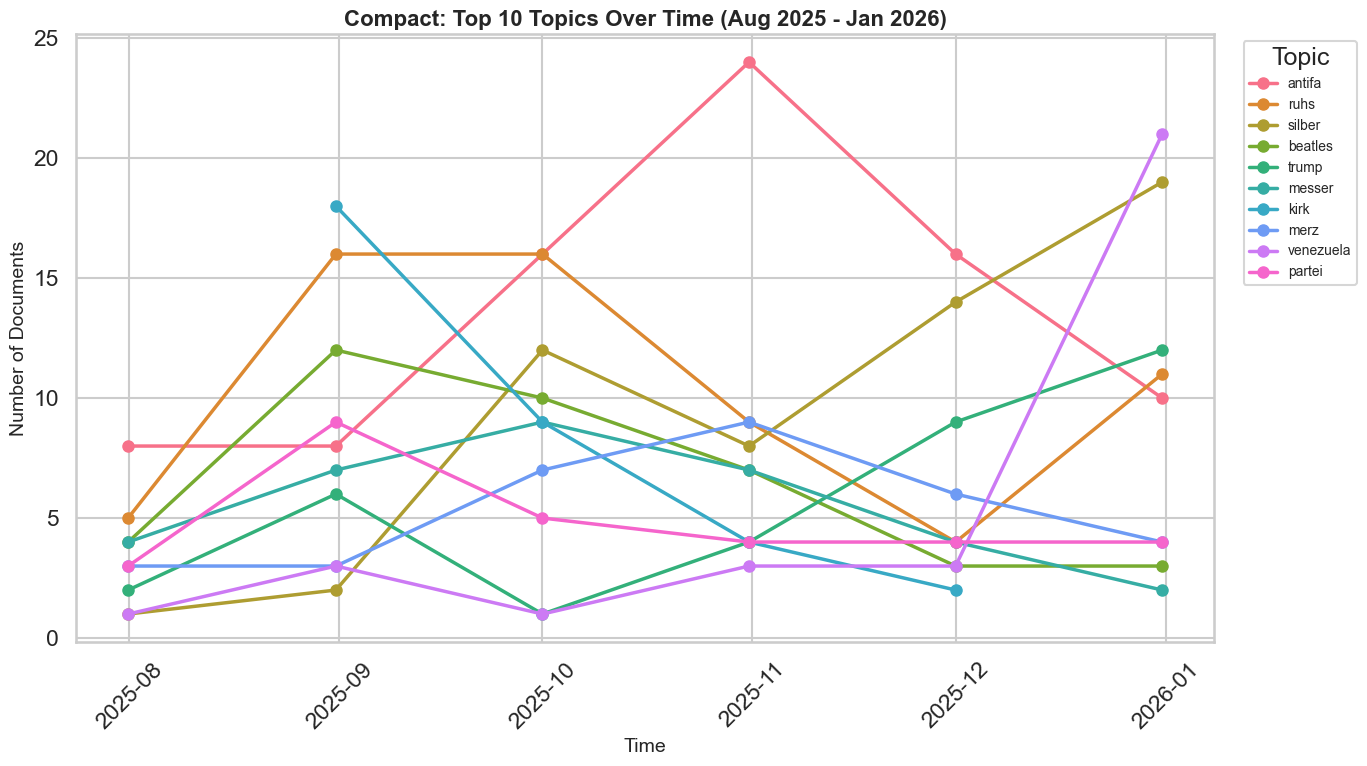

In [272]:
# Prepare data for topics over time
prepared_dates = pd.to_datetime(result["prepared_documents"]["Date"], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()
docs_for_time = [doc for doc, ok in zip(result["docs"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    nr_bins=6
)

# Get top 10 topics by count (excluding -1)
top_10_topics = topic_info[topic_info['Topic'] != -1].nlargest(10, 'Count')['Topic'].tolist()

# Filter for top 10 topics
topics_over_time_filtered = topics_over_time[topics_over_time['Topic'].isin(top_10_topics)]

# Create topic name mapping
topic_name_map = dict(zip(topic_info['Topic'], topic_info['Name']))

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered['Topic'] == topic]
    label = topic_name_map.get(topic, f"Topic {topic}")
    # Shorten label for legend
    short_label = label.split('_')[1] if '_' in label else label
    ax.plot(topic_data['Timestamp'], topic_data['Frequency'], 
            marker='o', linewidth=2.5, markersize=8, 
            color=palette[i], label=short_label)

ax.set_xlabel('Time', fontsize=14)
ax.set_ylabel('Number of Documents', fontsize=14)
ax.set_title('Compact: Top 10 Topics Over Time (Aug 2025 - Jan 2026)', fontsize=16, fontweight='bold')
ax.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [273]:
# Final BERTopic comparison table: all topics + representative words
from IPython.display import display

topics_comparison_df = topic_info[["Topic", "Name", "Count"]].copy()

def _representative_words_for_topic(topic_id: int) -> str:
    terms = result["topic_model"].get_topic(int(topic_id)) or []
    return ", ".join(word for word, _ in terms)

topics_comparison_df["Representative_Words"] = topics_comparison_df["Topic"].apply(_representative_words_for_topic)
topics_comparison_df = topics_comparison_df.sort_values("Topic").reset_index(drop=True)

with pd.option_context("display.max_colwidth", None, "display.width", 220):
    display(topics_comparison_df)


,Topic,Name,Count,Representative_Words
0,-1,-1_russland_berlin_merz_krieg,475,"russland, berlin, merz, krieg, mann, us, partei, ukraine, naidoo, später, politische, zwar, ihrem, dezember, buch, frieden, paul, nord, ihm, spd, regierung, natürlich, nord stream, stream, 14, frage, tag, deutsch, druschba, eu"
1,0,0_antifa_wehrpflicht_chrupalla_weidel,82,"antifa, wehrpflicht, chrupalla, weidel, beifall, beifall afd, höcke, szene, partei, grünen, 90, lucassen, alice, alice weidel, 90 grünen, gießen, bündnis, bündnis 90, polizei, linke, linken, baumann, tino chrupalla, gewalt, tino, demonstration, wiedereinführung, bundestag, wiedereinführung wehrpflicht, bundestagsfraktion"
2,1,1_ruhs_buch_julia ruhs_julia,61,"ruhs, buch, julia ruhs, julia, wahrheit, gesteuerte wahrheit, röper, gesteuerte, links, bystron, combs, brd, journalisten, spiegel, meinungsfreiheit, weimer, links grüne, mich, stadtbild, diddy, ihrem, mainstream, freimaurer, grüne, kritik, meinung, linke, sagen, bolz, öffentlich"
3,2,2_silber_gold_dollar_silbermedaillen,56,"silber, gold, dollar, silbermedaillen, preis, medaillen, edelmetalle, silberpreis, us, geld, 2026, edelmetall, unze, putin, anleger, goldes, januar, druschba, us dollar, trump, november, höcke, gold silber, pro, jahr goldes, wert, fed, billionen, preise, nachfrage"
4,3,3_beatles_geheime_geheime geschichte_kabale,39,"beatles, geheime, geheime geschichte, kabale, pharaonen, vatikan, nazca, geschichte pharaonen, kabale vatikan, pharaonen kabale, linien, geheimnis, römischen, buch, chr, forscher, janich, jesus, reiche, unserer geheime, otto, jahrhundert, däniken, entdeckt, entdeckung, moses, hallstatt, gott, überreste, of"
5,4,4_trump_donald_europa_us,34,"trump, donald, europa, us, donald trump, trumps, eu, europäischen, präsident, frohnmaier, us präsident, usa afd, kurs, chrupalla, staaten, europas, ukraine, nationen, washington, liebschaft, gefährliche liebschaft, rußland, gefährliche, weidel, un, tino chrupalla, tino, plan, europäische, kritik"
6,5,5_messer_asyl_messer morde_mädchen messer,33,"messer, asyl, messer morde, mädchen messer, morde, mädchen, merz, migranten, opfer, 2015, täter, polizei, asyl invasion, invasion, asylbewerber, migration, bürgermeister, deutlich, asylheim, 14, bürger, grenzöffnung, fürstenwalde, 14 99, zuwanderung, 99, 99 euro, zahlen, statt 38, 38 40"
7,6,6_kirk_charlie_charlie kirk_owens,33,"kirk, charlie, charlie kirk, owens, mord, trump, attentat, attentate, tiefen, kirks, carlson, tiefen staates, kugel, candace owens, candace, fbi, staates, konservativen, turning, turning point, us, point, fuentes, attentate tiefen, schuss, maga, lennon, utah, ermordung, campus"
8,7,7_merz_kanzler_friedrich merz_friedrich,32,"merz, kanzler, friedrich merz, friedrich, weimer, china, regierung, union, wadephul, ju, teilzeit, bsw, spd, bundestag, spiegel, wagenknecht, wolfram, partei, wolfram weimer, schwarz, taiwan, arbeiten, insa, stunden, the european, weidel, sahra wagenknecht, sahra, reden, european"
9,8,8_venezuela_maduro_us_caracas,32,"venezuela, maduro, us, caracas, washington, präsident, trump, venezuelas, staaten, öl, venezolanischen, cia, vereinigten staaten, vereinigten, drogen, angriff, aggression, china, amerikanische, nicolas, küste, nicolas maduro, operation, militärische, maduros, venezolanische, daniele, gegen venezuela, politische, imperium usa"


In [274]:
print("Legacy experimental BERTopic v2 run removed. The canonical Compact model uses the standard pipeline above and is saved to outputs/compact_model.")


Experimental BERTopic v2 run removed. The saved final Compact model uses the standard BERTopic pipeline above.


In [286]:
from pathlib import Path
import shutil
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_full_text).
base_result = result_full_text
topic_model_base = base_result["topic_model"]
docs_cm = list(base_result["docs"])
topics_cm = list(base_result["topics"])
baseline_topic_ids = {topic for topic in topics_cm if topic != -1}
has_outliers = -1 in topics_cm

if has_outliers:
    new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
        docs_cm,
        topics_cm,
        strategy="c-tf-idf",
        threshold=0.10,
    )
    new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)
else:
    print("No outliers found in the Compact baseline model; skipping reduce_outliers and saving the baseline model as final.")
    new_topics_ctfidf_threshold = list(topics_cm)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
if has_outliers:
    vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
    ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
    representation_same = deepcopy(topic_model_base.representation_model)

    topic_model_ctfidf_threshold.update_topics(
        docs_cm,
        topics=new_topics_ctfidf_threshold,
        vectorizer_model=vectorizer_same,
        ctfidf_model=ctfidf_same,
        representation_model=representation_same,
        top_n_words=topic_model_base.top_n_words,
    )
    topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)


topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(
    r"^\d+_", "", regex=True
)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[
        topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]
    ]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(
    zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"])
)
display_label_map = dict(
    zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"])
)

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_compact = dict(base_result)
result_compact["topics"] = list(new_topics_ctfidf_threshold)
result_compact["topic_model"] = topic_model_ctfidf_threshold
result_compact["topic_info"] = topic_info_ctfidf_threshold
result_compact["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_compact["doc_info"] = doc_info_reduced
result_compact["display_topic_map"] = display_topic_map
result_compact["display_label_map"] = display_label_map

# Keep a reusable reduced result dict in notebook memory and make it the current Compact result.
result = result_compact
topic_info = result["topic_info"]

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
# Save the canonical final Compact model used downstream and by the merged-model workflow.
save_dir = project_root / "02_TopicModeling" / "outputs" / "compact_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)

if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_cm) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(set(t for t in new_topics_ctfidf_threshold if t != -1)),
    },
])

display(summary_final)
display(topic_info_ctfidf_threshold.head(30))
print(f"Saved final reduced Compact model to: {save_dir}")

2026-03-31 19:10:47,721 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
2026-03-31 19:10:48,218 - BERTopic - Topic reduction - Reducing number of topics
2026-03-31 19:10:48,222 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 19:10:48,699 - BERTopic - Representation - Completed ✓
2026-03-31 19:10:48,700 - BERTopic - Topic reduction - Reduced number of topics from 43 to 25


After reduce_topics(25): 24 topics, 190 outliers


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,475,42
1,ctfidf_0.10 + reduce_topics(25),190,24


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_naidoo_zitat_zitat tages_klima,-1,190,-1_naidoo_zitat_zitat tages_klima,"[naidoo, zitat, zitat tages, klima, dezember, demozid, orzechowski, hamburg, elsässer, kirche, berlin, deutsch, xavier, geoengineering, liebe, xavier naidoo, chaos, shlomo, dominik reichert, längst, reichert, wetter, dominik, kioske, printausgabe, printausgabe erst, dezember kioske, überlastung spedition, spedition kommt, kommt printausgabe]","[AfD deckt auf: Regierung manipuliert Wetter. Dreht die Bundesregierung per Geoengineering am Wetter, um die sogenannte Klimarettung voranzutreiben? Diesen Vorwurf erhebt die AfD im Bundestag und muss sich dafür vom politischen Gegner vorhalten lassen, eine absurde Theorie zu verbreiten. Doch ist das wirklich Unsinn? COMPACT-Spezial „Klima-Terroristen“ klärt auf. Hier mehr erfahren. Die AfD-Fraktion im Bundestag hat das Thema Wettermanipulation auf den Tisch gebracht. In einem aktuellen Antrag fordern die Blauen die Regierung unter anderem auf, „eine Prüfung der Sicherheitslage bezüglich der möglichen Auswirkung des Geoengineerings (…) durchzuführen“ und Regelungen vorzulegen, die den Einsatz von großflächigem Geoengineering mit Ausnahme überwachter Forschungsvorhaben in Deutschland untersagen“. COMPACT berichtet: Die Debatte um Wettermanipulation ist auch Thema des heutigen n Am besten, Sie abonnieren gleich unseren Youtube-Kanal und aktivieren die Glocke, um keine Sendung mehr zu..."
1,0,1,Topic 1 — partei_cdu_spd_weidel,partei_cdu_spd_weidel,0,197,0_partei_cdu_spd_weidel,"[partei, cdu, spd, weidel, antifa, höcke, alice, wehrpflicht, alice weidel, bsw, chrupalla, grünen, sachsen, blauen, patzelt, linke, tino, parteien, björn, björn höcke, tino chrupalla, umfrage, linken, bündnis, union, erfolg, brandenburg, brandmauer, thüringer, csu]","[Weidels große Abrechnung zum Nachlesen. Höhepunkt der vergangenen Sitzungswoche im Bundestag war die große Abrechnung der AfD-Oppositionsführerin mit dem Bundeskanzler rund um die Haushaltsberatungen. Wir dokumentieren sie nachfolgend im Wortlaut. COMPACT hat die die Kanzlermedaille Alice Weidel auf den Markt gebracht, ein Schmuckstück in Silber. Hier mehr erfahren. Dr. Alice Weidel: Sehr geehrte Frau Präsidentin! Sehr geehrter Herr Bundeskanzler! Sehr geehrte Damen und Herren! Die Bürger werden ungeduldig, Herr Merz. Sie warten darauf, dass Sie sich aus Ihrer Selbstgefälligkeit und links-grünen Realitätsverweigerung hinausbewegen. Kein Wort von Ihnen zum heimtückischen politischen Mord an Charlie Kirk, dessen Tod nicht nur die USA erschüttert hat. Er war ein Konservativer, ein gläubiger Christ, ein mutiger Verteidiger der Werte, für die auch Ihre Partei vor langer Zeit einmal stand. (Beifall bei der AfD) Charlie Kirk war ein überzeugter Verfechter der freien Rede und der offenen ..."
2,1,2,Topic 2 — cdu_spd_brd_000 seiten,cdu_spd_brd_000 seiten,1,180,1_cdu_spd_brd_000 seiten,"[cdu, spd, brd, 000 seiten, partei, brd diktatur, diktatur, seiten brd, 75, 14, 79, 14 99, 99, 79 75, ruhs, 75 euro, kanzler, weimer, demokratie, 99 euro, friedrich merz, euro statt, julia, für 14, friedrich, stimmen, julia ruhs, kritik, links, statt für]","[AfD-Ausschluss: „Es ist verfassungswidrig!“. Ein Skandal schlägt weiter hohe Wellen: Der Wahlausschuss hat den aussichtsreichen AfD-Landtagsabgeordneten Joachim Paul von der Oberbürgermeisterwahl in Ludwigshafen ausgeschlossen – ein Eklat. Sichern Sie sich unser Rabatt-Paket „1000 Seiten BRD-Diktatur“, jetzt für 14,99 Euro statt für 79,75 Euro. Hier mehr erfahren. Ein ungeheuerlicher Angriff auf die Demokratie: Joachim Paul wurde auf Basis einer abstrusen Verfassungsschutz-Zitatensammlung, die von Internet-Recherchen bis zu einer „Herr der Ringe“-Rezension reicht, von der Wahl zum OB in Ludwigshafen ausgeschlossen. Unter Vorsitz der ehemaligen SPD-Politikerin Jutta Steinruck zweifelte der Wahlausschuss Pauls Verfassungstreue a

Saved final reduced Compact model to: /Users/MattisHaumann/Dev/Thesis/02_TopicModeling/outputs/compact_model


In [287]:
topic_model = result_compact["topic_model"]

In [289]:
topic_model = result_compact["topic_model"]

for topic_id in topic_model.get_topic_info()["Topic"]:
    print(f"\n=== Topic {topic_id} ===")
    display(pd.DataFrame(topic_model.get_topic(int(topic_id)), columns=["keyword", "weight"]))



=== Topic -1 ===


,keyword,weight
0,naidoo,0.010099
1,zitat,0.009082
2,zitat tages,0.008860
3,klima,0.008001
4,dezember,0.007249
5,demozid,0.007107
6,orzechowski,0.007054
7,hamburg,0.006661
8,elsässer,0.006433
9,kirche,0.006361



=== Topic 0 ===


,keyword,weight
0,partei,0.016926
1,cdu,0.015641
2,spd,0.013431
3,weidel,0.013096
4,antifa,0.013044
5,höcke,0.012348
6,alice,0.010870
7,wehrpflicht,0.010865
8,alice weidel,0.010795
9,bsw,0.010208



=== Topic 1 ===


...

,keyword,weight
0,abdulmohsen,0.066439
1,al,0.056903
2,al abdulmohsen,0.054479
3,taleb,0.036956
4,taleb al,0.035283
5,morde,0.034787
6,weihnachtsmarkt,0.034265
7,messer,0.032245
8,mädchen messer,0.031830
9,messer morde,0.031830



=== Topic 22 ===


,keyword,weight
0,eu,0.069937
1,moldawien,0.032769
2,brüssel,0.028585
3,kallas,0.027835
4,rumänien,0.026505
5,russland,0.024468
6,moldawiens,0.022049
7,partei,0.020991
8,tschechien,0.018940
9,babis,0.017639



=== Topic 23 ===


,keyword,weight
0,musk,0.099520
1,elon,0.075917
2,mars,0.068377
3,elon musk,0.068137
4,spacex,0.032496
5,planeten,0.029824
6,tommy,0.028886
7,musks,0.022107
8,tommy robinson,0.020515
9,robinson,0.019298


In [291]:
from pathlib import Path
import shutil

# Optional re-save of the already chosen final Compact model to the same canonical outputs path.
save_dir = Path("/Users/MattisHaumann/Dev/Thesis/02_TopicModeling/outputs/compact_model")
save_dir.parent.mkdir(parents=True, exist_ok=True)

if save_dir.exists():
    shutil.rmtree(save_dir)

# Save the current topic_model (fallbacks included if variable names differ)
model_to_save = globals().get("topic_model") or globals().get("topic_model_ctfidf_threshold") or globals().get("topic_model_base")
if model_to_save is None:
    raise RuntimeError("No BERTopic model found in the notebook (topic_model / topic_model_ctfidf_threshold / topic_model_base).")

model_to_save.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved canonical final Compact model to: {save_dir}")

Saved Compact model to: /Users/MattisHaumann/Dev/Thesis/02_TopicModeling/outputs/compact_model
